# Chapter 1 — Economic Growth: Profiling & Reshaping

Profiles the raw WDI export, separates real countries from aggregates, and builds the cleaned long-format Chapter 1 panel.

**Outputs:**
- `data/processed/chapter1_economic_growth_panel.csv`
- `data/processed/chapter1_missingness_by_decade.csv`

**Methodology:** `docs/methodology/chapter1_economic_growth_cleaning.md`

In [1]:
pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd

# Section 1 — Understand what you actually have
1. Load your raw WDI export. Report: total row count, number of
unique “Country Name” values, number of unique indicators, and
the year range covered.
3. Missing values in WDI exports are usually represented as blank
cells or ".." rather than a clean NaN. Confirm how missingness is
encoded in your file, and report the overall missing-value rate.

In [2]:
world_bank = pd.ExcelFile("/Users/abhishek/Desktop/world-bank-indicators-project/WDIEXCEL.xlsx")

In [3]:
WB_data = pd.read_excel(world_bank,"Data")

In [4]:
#total row count
len(WB_data)

396970

In [5]:
WB_data.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025'],
      dtype='object')

In [6]:
#number of unique “Country Name” values
len(WB_data["Country Name"].unique())

265

In [7]:
#number of unique indicators
len(WB_data["Indicator Name"].unique())

1498

In [8]:
#the year range covered
#how to find the year range covered
year_cols = []
for col in WB_data.columns:
    if col.isdigit():
        year_cols.append(col)
    
print(f"Year range: {min(year_cols)} to {max(year_cols)}")

Year range: 1960 to 2025


# Section 1 Part - 2. 
The World Bank’s country list is not just countries — it also
includes aggregates like “World,” “East Asia & Pacific,” “Low
income,” “OECD members,” etc., mixed in as if they were
countries. Identify how many of your “Country Name” values are
actually real countries versus regional/income-group aggregates.
(Hint: the World Bank publishes a country metadata list with a
“Region” field — real countries have a non-null region; aggregates
typically don’t.)

In [9]:
WB_data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,50.667516,52.598171,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.998179,35.240236,36.080572,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396965,Zimbabwe,ZWE,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
396966,Zimbabwe,ZWE,Women who were first married by age 15 (% of w...,SP.M15.2024.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.400000,NaN,NaN,NaN,NaN,NaN,NaN
396967,Zimbabwe,ZWE,Women who were first married by age 18 (% of w...,SP.M18.2024.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,33.700000,NaN,NaN,NaN,NaN,NaN,NaN
396968,Zimbabwe,ZWE,Women's share of population ages 15+ living wi...,SH.DYN.AIDS.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,58.916636,59.131787,59.318579,59.495248,59.675019,59.832577,59.955283,60.053675,60.155308,NaN


In [10]:
WB_ctry = pd.read_excel(world_bank,'Country')

In [11]:
WB_ctry

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,NaN,Latin America & Caribbean,High income,AW,...,NaN,Enhanced General Data Dissemination System (e-...,2020 (expected),NaN,NaN,Yes,NaN,NaN,2018.0,NaN
1,AFE,Africa Eastern and Southern,Africa Eastern and Southern,Africa Eastern and Southern,ZH,NaN,"26 countries, stretching from the Red Sea in t...",NaN,NaN,ZH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,The reporting period for national accounts dat...,Middle East & North Africa,Low income,AF,...,Consolidated central government,Enhanced General Data Dissemination System (e-...,1979,Multiple Indicator Cluster Survey 2022-2023,"Integrated household survey (IHS), 2016/17",NaN,2003.0,NaN,2018.0,NaN
3,AFW,Africa Western and Central,Africa Western and Central,Africa Western and Central,ZI,NaN,"22 countries, stretching from the westernmost ...",NaN,NaN,ZI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,The World Bank systematically assesses the app...,Sub-Saharan Africa,Lower middle income,AO,...,Budgetary central government,Enhanced General Data Dissemination System (e-...,2014,Inquérito de Indicadores Múltiplos e de Saúde ...,"Integrated household survey (IHS), 2008/09",NaN,2023.0,NaN,2018.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,XKX,Kosovo,Kosovo,Republic of Kosovo,XK,Euro,NaN,Europe & Central Asia,Upper middle income,XK,...,NaN,Enhanced General Data Dissemination System (e-...,2011,Multiple Indicator Cluster Survey 2019-2020,"Expenditure survey/budget survey (ES/BS), 2015",NaN,2020.0,NaN,NaN,NaN
260,YEM,"Yemen, Republic of","Yemen, Rep.",Republic of Yemen,YE,Yemeni rial,The World Bank systematically assesses the app...,Middle East & North Africa,Low income,RY,...,NaN,Enhanced General Data Dissemination System (e-...,2004,National Health and Demographic Survey 2013,"Expenditure survey/budget survey (ES/BS), 2014",NaN,2002.0,2012.0,2015.0,NaN
261,ZAF,South Africa,South Africa,Republic of South Africa,ZA,South African rand,Fiscal year end: March 31; reporting period fo...,Sub-Saharan Africa,Upper middle income,ZA,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2022,Demographic and Health Survey 2016,"Expenditure survey/budget survey (ES/BS), 2014/15",NaN,2018.0,2010.0,2018.0,NaN
262,ZMB,Zambia,Zambia,Republic of Zambia,ZM,New Zambian kwacha,National accounts data were rebased to reflect...,Sub-Saharan Africa,Lower middle income,ZM,...,Budgetary central government,Enhanced General Data Dissemination System (e-...,2022,Demographic and Health Survey 2018,"Integrated household survey (IHS), 2015",NaN,2000.0,1994.0,2018.0,NaN


In [12]:
#NUMBER OF REAL COUNTRIES
WB_ctry['Region'].notna().sum()

np.int64(217)

# Section 1 Part 3 
Missing values in WDI exports are usually represented as blank
cells or ".." rather than a clean NaN. Confirm how missingness is
encoded in your file, and report the overall missing-value rate.

In [13]:
#pd.set_option('display.max_rows', None)

WB_data[year_cols].dtypes

1960    float64
1961    float64
1962    float64
1963    float64
1964    float64
         ...   
2021    float64
2022    float64
2023    float64
2024    float64
2025    float64
Length: 66, dtype: object

In [14]:
WB_data_true_raw = pd.read_excel(world_bank, "Data", dtype=str, keep_default_na=False, na_values=[])
WB_data_true_raw['2024'].value_counts(dropna=False).head(5)

2024
       246812
100      1166
0        1066
6         559
3         489
Name: count, dtype: int64

In [15]:
(WB_data_true_raw[year_cols]=='').sum().sum()

np.int64(17184106)

In [16]:
(WB_data_true_raw[year_cols]=='..').sum().sum()

np.int64(0)

# Missingness Encoding

The missing values are encoded in form of blank cells in the data

In [17]:
#overall missing value rate
((WB_data_true_raw[year_cols]=='').sum().sum())*100/(WB_data_true_raw[year_cols].count()).sum()

np.float64(65.58814077241162)

In [18]:
WB_data

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,18.685118,19.205632,19.742772,20.332679,20.862800,21.419621,21.996456,22.541440,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.606712,7.926604,8.309896,8.704591,9.106640,9.480804,9.903209,10.288154,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,39.052626,39.321068,39.649534,39.968299,40.354628,40.723805,41.026351,41.289974,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,50.667516,52.598171,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,24.584906,25.375037,26.941984,28.983183,30.909991,32.709837,33.998179,35.240236,36.080572,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396965,Zimbabwe,ZWE,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
396966,Zimbabwe,ZWE,Women who were first married by age 15 (% of w...,SP.M15.2024.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.400000,NaN,NaN,NaN,NaN,NaN,NaN
396967,Zimbabwe,ZWE,Women who were first married by age 18 (% of w...,SP.M18.2024.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,33.700000,NaN,NaN,NaN,NaN,NaN,NaN
396968,Zimbabwe,ZWE,Women's share of population ages 15+ living wi...,SH.DYN.AIDS.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,58.916636,59.131787,59.318579,59.495248,59.675019,59.832577,59.955283,60.053675,60.155308,NaN


In [19]:
WB_ctry

,Country Code,Short Name,Table Name,Long Name,2-alpha code,Currency Unit,Special Notes,Region,Income Group,WB-2 code,...,Government Accounting concept,IMF data dissemination standard,Latest population census,Latest household survey,Source of most recent Income and expenditure data,Vital registration complete,Latest agricultural census,Latest industrial data,Latest trade data,Latest water withdrawal data
0,ABW,Aruba,Aruba,Aruba,AW,Aruban florin,NaN,Latin America & Caribbean,High income,AW,...,NaN,Enhanced General Data Dissemination System (e-...,2020 (expected),NaN,NaN,Yes,NaN,NaN,2018.0,NaN
1,AFE,Africa Eastern and Southern,Africa Eastern and Southern,Africa Eastern and Southern,ZH,NaN,"26 countries, stretching from the Red Sea in t...",NaN,NaN,ZH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,Afghanistan,Islamic State of Afghanistan,AF,Afghan afghani,The reporting period for national accounts dat...,Middle East & North Africa,Low income,AF,...,Consolidated central government,Enhanced General Data Dissemination System (e-...,1979,Multiple Indicator Cluster Survey 2022-2023,"Integrated household survey (IHS), 2016/17",NaN,2003.0,NaN,2018.0,NaN
3,AFW,Africa Western and Central,Africa Western and Central,Africa Western and Central,ZI,NaN,"22 countries, stretching from the westernmost ...",NaN,NaN,ZI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AGO,Angola,Angola,People's Republic of Angola,AO,Angolan kwanza,The World Bank systematically assesses the app...,Sub-Saharan Africa,Lower middle income,AO,...,Budgetary central government,Enhanced General Data Dissemination System (e-...,2014,Inquérito de Indicadores Múltiplos e de Saúde ...,"Integrated household survey (IHS), 2008/09",NaN,2023.0,NaN,2018.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259,XKX,Kosovo,Kosovo,Republic of Kosovo,XK,Euro,NaN,Europe & Central Asia,Upper middle income,XK,...,NaN,Enhanced General Data Dissemination System (e-...,2011,Multiple Indicator Cluster Survey 2019-2020,"Expenditure survey/budget survey (ES/BS), 2015",NaN,2020.0,NaN,NaN,NaN
260,YEM,"Yemen, Republic of","Yemen, Rep.",Republic of Yemen,YE,Yemeni rial,The World Bank systematically assesses the app...,Middle East & North Africa,Low income,RY,...,NaN,Enhanced General Data Dissemination System (e-...,2004,National Health and Demographic Survey 2013,"Expenditure survey/budget survey (ES/BS), 2014",NaN,2002.0,2012.0,2015.0,NaN
261,ZAF,South Africa,South Africa,Republic of South Africa,ZA,South African rand,Fiscal year end: March 31; reporting period fo...,Sub-Saharan Africa,Upper middle income,ZA,...,Consolidated central government,Special Data Dissemination Standard (SDDS),2022,Demographic and Health Survey 2016,"Expenditure survey/budget survey (ES/BS), 2014/15",NaN,2018.0,2010.0,2018.0,NaN
262,ZMB,Zambia,Zambia,Republic of Zambia,ZM,New Zambian kwacha,National accounts data were rebased to reflect...,Sub-Saharan Africa,Lower middle income,ZM,...,Budgetary central government,Enhanced General Data Dissemination System (e-...,2022,Demographic and Health Survey 2018,"Integrated household survey (IHS), 2015",NaN,2000.0,1994.0,2018.0,NaN


In [20]:
#my job is to join both the datasets. with not na Region ok
WB_ctry.columns

Index(['Country Code', 'Short Name', 'Table Name', 'Long Name', '2-alpha code',
       'Currency Unit', 'Special Notes', 'Region', 'Income Group', 'WB-2 code',
       'National accounts base year', 'National accounts reference year',
       'SNA price valuation', 'Lending category', 'Other groups',
       'System of National Accounts', 'Alternative conversion factor',
       'PPP survey year', 'Balance of Payments Manual in use',
       'External debt Reporting status', 'System of trade',
       'Government Accounting concept', 'IMF data dissemination standard',
       'Latest population census', 'Latest household survey',
       'Source of most recent Income and expenditure data',
       'Vital registration complete', 'Latest agricultural census',
       'Latest industrial data', 'Latest trade data',
       'Latest water withdrawal data'],
      dtype='object')

In [21]:
WB_realctry= WB_ctry[WB_ctry['Region'].notna()]

In [22]:
WB_data_copy_ctry = WB_data.copy()

In [23]:
WB_data_real = WB_data_copy_ctry.merge(WB_realctry,on = "Country Code",how ="inner")

In [24]:
WB_data_copy_regional = WB_data.copy()

In [25]:
WB_data_regional = WB_data_copy_regional.merge(WB_ctry[WB_ctry['Region'].isna()], on = "Country Code", how = "inner")

# Justification for which one should we used for economic growth 
For economic growth I would like to use countries because aim of the study to compare different global south countries and what parameter and estimates lead to higher overall "development". Comparing by region would actually be more generic comparison as though the in a region we can see similar geographical conditions to growth and to an extent cultural conditions like we say indian subcontinent as one region but there are still vast differences among them in past 70 years in form of institutions in these countries. Two main cases. First, presentation simplicity: if you're showing GDP trajectories for fifteen countries to someone in Washington, individual lines become a hassle to parse — especially when several countries have similar trajectories. A regional or income-group average compresses that into one readable line.

Second, when the comparison itself is at the aggregate level — e.g., Southeast Asia vs. Sub-Saharan Africa — the region is the unit of interest, not a stand-in for countries.

A related case is the "Asian Tigers" — not a formal World Bank region, but a named cluster of countries whose growth story over the last three decades of the millennium is more meaningful told together than as separate lines.



# Reshaping to Long Format

In [26]:
WB_data_long = pd.melt(WB_data,
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],        # which columns stay as identifiers?
    var_name= 'Years', # what do you call the column that holds '1960', '1961', etc.?
    value_name= 'Value', # what do you call the column that holds the values?
    value_vars = ['1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025']
)

In [27]:
WB_data.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025'],
      dtype='object')

In [28]:
WB_data_long

,Country Name,Country Code,Indicator Name,Indicator Code,Years,Value
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN
...,...,...,...,...,...,...
26200015,Zimbabwe,ZWE,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,2025,NaN
26200016,Zimbabwe,ZWE,Women who were first married by age 15 (% of w...,SP.M15.2024.FE.ZS,2025,NaN
26200017,Zimbabwe,ZWE,Women who were first married by age 18 (% of w...,SP.M18.2024.FE.ZS,2025,NaN
26200018,Zimbabwe,ZWE,Women's share of population ages 15+ living wi...,SH.DYN.AIDS.FE.ZS,2025,NaN


In [29]:
WB_data_long['Value'].head(20)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: Value, dtype: float64

In [30]:
WB_data_true_raw[year_cols].head(20)


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,,,,,,,,,,,...,18.68511838055394,19.205632430461566,19.74277232561877,20.332678973479805,20.862800066556645,21.419620740007513,21.996456231910123,22.54144021276354,,
1,,,,,,,,,,,...,7.606712056855138,7.9266044460251335,8.309895632499256,8.704590789736665,9.106639547425047,9.480803898591947,9.903208961847541,10.288153897517871,,
2,,,,,,,,,,,...,39.05262615876516,39.32106815800108,39.64953356464245,39.96829860397896,40.35462821357813,40.723805178702015,41.026350512054854,41.289974160063146,,
3,,,,,,,,,,,...,38.85959765837143,40.22374417303677,43.03507335078355,44.39086053336394,46.28237094556367,48.12721104004846,48.74204293751769,50.667515794485425,52.598170516358906,
4,,,,,,,,,,,...,24.584906329205204,25.375037416544444,26.941983663114215,28.9831827826011,30.90999097009688,32.709836554053545,33.99817868023432,35.240236286980206,36.08057156580783,
5,,,,,,,,,,,...,69.11567254585054,70.94703589962732,71.8169384248205,72.95584408313286,74.37711818464983,75.8419966667537,76.27701441573845,80.64955894791925,80.04927404964874,
6,,,,,,,,,,,...,,,,,,,,,,
7,,,,,,,,,,,...,,,,,,,,,,
8,,,,,,,,,,,...,,,,,,,,,,
9,,,,,,,,,,,...,,,,,,,,,,


In [31]:
print("Empty strings:", (WB_data_true_raw[year_cols] == '').sum().sum())
print("'..' strings:", (WB_data_true_raw[year_cols] == '..').sum().sum())
print("NaN:", WB_data_true_raw[year_cols].isna().sum().sum())

Empty strings: 17184106
'..' strings: 0
NaN: 0


# Building the Chapter 1 Panel

In [32]:
# Filter WB_data_long to real countries
countries = WB_ctry.loc[WB_ctry['Region'].notna(),'Country Code']

In [33]:
countries.index

Index([  0,   2,   4,   5,   6,   8,   9,  10,  11,  12,
       ...
       253, 254, 255, 256, 258, 259, 260, 261, 262, 263],
      dtype='int64', length=217)

In [34]:
WB_long_filter = WB_data_long[WB_data_long['Country Code'].isin(countries)]

In [35]:
WB_long_filter

,Country Name,Country Code,Indicator Name,Indicator Code,Years,Value
71904,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,1960,NaN
71905,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,1960,NaN
71906,Afghanistan,AFG,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,1960,NaN
71907,Afghanistan,AFG,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
71908,Afghanistan,AFG,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,1960,NaN
...,...,...,...,...,...,...
26200015,Zimbabwe,ZWE,Women who believe a husband is justified in be...,SG.VAW.REFU.ZS,2025,NaN
26200016,Zimbabwe,ZWE,Women who were first married by age 15 (% of w...,SP.M15.2024.FE.ZS,2025,NaN
26200017,Zimbabwe,ZWE,Women who were first married by age 18 (% of w...,SP.M18.2024.FE.ZS,2025,NaN
26200018,Zimbabwe,ZWE,Women's share of population ages 15+ living wi...,SH.DYN.AIDS.FE.ZS,2025,NaN


GDP,PPP(constant international $)

GNI,PPP(constant international $)

Final consumption expenditure(% of GDP) - general government

Final consumption expenditure(% of GDP) - households and NPISHs

Gross capital formation (% of GDP)

In [36]:
indicatorsGrowth = ['GDP, PPP (constant international $)','GNI, PPP (constant international $)','Final consumption expenditure (% of GDP) — general government','Final consumption expenditure (% of GDP) — households and NPISHs'
,'Gross capital formation (% of GDP)']

In [37]:
WB_data_economicgrowth = WB_data_long[WB_data_long['Indicator Name'].isin(indicatorsGrowth)]

In [38]:
WB_data_economicgrowth

,Country Name,Country Code,Indicator Name,Indicator Code,Years,Value
565,Africa Eastern and Southern,AFE,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,1960,NaN
2063,Africa Western and Central,AFW,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,1960,NaN
3561,Arab World,ARB,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,1960,NaN
5059,Caribbean small states,CSS,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,1960,NaN
6557,Central Europe and the Baltics,CEB,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,1960,NaN
...,...,...,...,...,...,...
26193095,Virgin Islands (U.S.),VIR,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,2025,NaN
26194593,West Bank and Gaza,PSE,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,2025,25.589063
26196091,"Yemen, Rep.",YEM,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,2025,NaN
26197589,Zambia,ZMB,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,2025,NaN


You noted in your own outline that you want to compare private vs. government final consumption, but weren't sure whether "final consumption expenditure" already nets in government spending, or whether household+NPISH and general government are meant to be summed to get the total. Resolve this ambiguity by checking whether  (household+NPISH) + (general government) sums to a separate "total final consumption expenditure" indicator, if one exists in your data. Report what you find.

In [39]:
pd.unique(WB_data['Indicator Name'][WB_data['Indicator Name'].str.contains("Final consumption expenditure",case= False)])

array(['Final consumption expenditure (% of GDP)',
       'Final consumption expenditure (annual % growth)',
       'Final consumption expenditure (constant 2015 US$)',
       'Final consumption expenditure (constant LCU)',
       'Final consumption expenditure (current LCU)',
       'Final consumption expenditure (current US$)',
       'General government final consumption expenditure (% of GDP)',
       'General government final consumption expenditure (annual % growth)',
       'General government final consumption expenditure (constant 2015 US$)',
       'General government final consumption expenditure (constant LCU)',
       'General government final consumption expenditure (current LCU)',
       'General government final consumption expenditure (current US$)',
       'Households and NPISHs final consumption expenditure (% of GDP)',
       'Households and NPISHs Final consumption expenditure (annual % growth)',
       'Households and NPISHs Final consumption expenditure (constant

In [40]:
india_2015 = WB_data_long[
    (WB_data_long['Country Name'] == 'India') &
    (WB_data_long['Years'] == '2015') &
    (WB_data_long['Indicator Name'].isin([
        'Final consumption expenditure (% of GDP)',
        'General government final consumption expenditure (% of GDP)',
        'Households and NPISHs final consumption expenditure (% of GDP)'
    ]))
]

In [41]:
india_2015

,Country Name,Country Code,Indicator Name,Indicator Code,Years,Value
22039034,India,IND,Final consumption expenditure (% of GDP),NE.CON.TOTL.ZS,2015,69.435572
22039104,India,IND,General government final consumption expenditu...,NE.CON.GOVT.ZS,2015,10.428291
22039179,India,IND,Households and NPISHs final consumption expend...,NE.CON.PRVT.ZS,2015,59.007281


In [42]:
pd.unique(WB_data_long['Indicator Code'][WB_data_long['Indicator Name'].str.contains('GNI, PPP',case= False)])

array(['NY.GNP.MKTP.PP.KD', 'NY.GNP.MKTP.PP.CD'], dtype=object)

In [43]:
pd.unique(WB_data_long['Indicator Code'][WB_data_long['Indicator Name'].str.contains('GDP, PPP',case= False)])

array(['NY.GDP.MKTP.PP.KD', 'NY.GDP.MKTP.PP.CD'], dtype=object)

In [44]:
pd.unique(WB_data_long['Indicator Code'][WB_data_long['Indicator Name'] =='Gross capital formation (% of GDP)'])

array(['NE.GDI.TOTL.ZS'], dtype=object)

In [45]:
WB_data_long[WB_data_long['Indicator Code'].isin(['NY.GDP.MKTP.PP.KD', 'NY.GNP.MKTP.PP.KD'])]['Indicator Name'].unique()

array(['GDP, PPP (constant 2021 international $)',
       'GNI, PPP (constant 2021 international $)'], dtype=object)

In [46]:
chapter1_panel = WB_long_filter[
    WB_long_filter['Indicator Code'].isin(['NY.GDP.MKTP.PP.KD','NY.GNP.MKTP.PP.KD','NE.CON.GOVT.ZS','NE.CON.PRVT.ZS','NE.GDI.TOTL.ZS'])
].copy()

In [47]:
chapter1_panel

,Country Name,Country Code,Indicator Name,Indicator Code,Years,Value
72429,Afghanistan,AFG,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,1960,NaN
72432,Afghanistan,AFG,General government final consumption expenditu...,NE.CON.GOVT.ZS,1960,NaN
72452,Afghanistan,AFG,"GNI, PPP (constant 2021 international $)",NY.GNP.MKTP.PP.KD,1960,NaN
72469,Afghanistan,AFG,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,1960,NaN
72507,Afghanistan,AFG,Households and NPISHs final consumption expend...,NE.CON.PRVT.ZS,1960,NaN
...,...,...,...,...,...,...
26199047,Zimbabwe,ZWE,"GDP, PPP (constant 2021 international $)",NY.GDP.MKTP.PP.KD,2025,9.372490e+10
26199050,Zimbabwe,ZWE,General government final consumption expenditu...,NE.CON.GOVT.ZS,2025,NaN
26199070,Zimbabwe,ZWE,"GNI, PPP (constant 2021 international $)",NY.GNP.MKTP.PP.KD,2025,NaN
26199087,Zimbabwe,ZWE,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,2025,NaN


In [48]:
import os
os.makedirs('/Users/abhishek/Desktop/world-bank-indicators-project/data/processed', exist_ok=True)

In [49]:
chapter1_panel.to_csv('/Users/abhishek/Desktop/world-bank-indicators-project/data/processed/chapter1_economic_growth_panel.csv', index=False)


In [50]:
os.path.exists('/Users/abhishek/Desktop/world-bank-indicators-project/data/processed/chapter1_economic_growth_panel.csv')

True

7. For each of the five indicators, report the missing-data rate by decade (1970s, 1980s, ... 2020s). Is missingness roughly random, or concentrated in certain time periods or country groups? One or two sentences is enough — just show you looked.


In [51]:
chapter1_panel['Decade'] = (chapter1_panel['Years'].astype(int) // 10) * 10

In [52]:
chapter1_panel['Decade']

72429       1960
72432       1960
72452       1960
72469       1960
72507       1960
            ... 
26199047    2020
26199050    2020
26199070    2020
26199087    2020
26199125    2020
Name: Decade, Length: 71610, dtype: int64

In [53]:
count = chapter1_panel.groupby(['Indicator Name','Decade'])['Value'].count()
# it gives us the total number of not null values

In [54]:
#how to find total number of null values per decade
size =chapter1_panel.groupby(['Indicator Name','Decade'])['Value'].size()


In [55]:
count

Indicator Name                                                  Decade
GDP, PPP (constant 2021 international $)                        1960         0
                                                                1970         0
                                                                1980         0
                                                                1990      1876
                                                                2000      1940
                                                                2010      1987
                                                                2020      1174
GNI, PPP (constant 2021 international $)                        1960         0
                                                                1970         0
                                                                1980         0
                                                                1990       886
                                                            

In [56]:
size

Indicator Name                                                  Decade
GDP, PPP (constant 2021 international $)                        1960      2170
                                                                1970      2170
                                                                1980      2170
                                                                1990      2170
                                                                2000      2170
                                                                2010      2170
                                                                2020      1302
GNI, PPP (constant 2021 international $)                        1960      2170
                                                                1970      2170
                                                                1980      2170
                                                                1990      2170
                                                            

In [57]:
chapter1_missingness_by_decade = (1-count/size)*100

In [58]:
chapter1_missingness_by_decade

Indicator Name                                                  Decade
GDP, PPP (constant 2021 international $)                        1960      100.000000
                                                                1970      100.000000
                                                                1980      100.000000
                                                                1990       13.548387
                                                                2000       10.599078
                                                                2010        8.433180
                                                                2020        9.831029
GNI, PPP (constant 2021 international $)                        1960      100.000000
                                                                1970      100.000000
                                                                1980      100.000000
                                                                1990       59.1

In [59]:
chapter1_missingness_by_decade.to_csv('/Users/abhishek/Desktop/world-bank-indicators-project/data/processed/chapter1_missingness_by_decade.csv', index=False)


In [60]:
import os
os.makedirs('/Users/abhishek/Desktop/world-bank-indicators-project/src', exist_ok=True)

In [61]:
import sys
sys.path.append('/Users/abhishek/Desktop/world-bank-indicators-project')

from src.reshape_utils import reshape_wdi

test = reshape_wdi(
    WB_data,
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
)
print(test.shape)

(26200020, 6)


In [62]:
pd.unique(WB_data['Indicator Name'][WB_data['Indicator Name'].str.contains('GDP per capita, PPP', case=False)])

array(['GDP per capita, PPP (constant 2021 international $)',
       'GDP per capita, PPP (current international $)'], dtype=object)

In [63]:
pd.unique(WB_data['Indicator Code'][WB_data['Indicator Name'] == 'GDP per capita, PPP (constant 2021 international $)'])

array(['NY.GDP.PCAP.PP.KD'], dtype=object)

Plot GDP PPP per capita over time for 4–5 countries of your choosing that make an interesting comparison (e.g., a fast catch-up economy vs. a stagnant one vs. a high-income baseline). No need for polish — this is about confirming your reshaped panel actually behaves like a panel should.


In [64]:
countries

0      ABW
2      AFG
4      AGO
5      ALB
6      AND
      ... 
259    XKX
260    YEM
261    ZAF
262    ZMB
263    ZWE
Name: Country Code, Length: 217, dtype: object

In [65]:
WB_data_long["Country Name"].unique()

array(['Africa Eastern and Southern', 'Africa Western and Central',
       'Arab World', 'Caribbean small states',
       'Central Europe and the Baltics', 'Early-demographic dividend',
       'East Asia & Pacific',
       'East Asia & Pacific (excluding high income)',
       'East Asia & Pacific (IDA & IBRD countries)', 'Euro area',
       'Europe & Central Asia',
       'Europe & Central Asia (excluding high income)',
       'Europe & Central Asia (IDA & IBRD countries)', 'European Union',
       'Heavily indebted poor countries (HIPC)', 'High income',
       'IBRD only', 'IDA & IBRD total', 'IDA blend', 'IDA only',
       'IDA total', 'Late-demographic dividend',
       'Latin America & Caribbean',
       'Latin America & Caribbean (excluding high income)',
       'Latin America & the Caribbean (IDA & IBRD countries)',
       'Least developed countries: UN classification',
       'Low & middle income', 'Low income', 'Lower middle income',
       'Middle East, North Africa, Afghanist

In [66]:
Ctys = ['United States','Viet Nam','China','India','Japan','Bangladesh']
for c in Ctys:
    print(c, c in WB_data['Country Name'].unique())

United States True
Viet Nam True
China True
India True
Japan True
Bangladesh True


In [67]:
Plot01 =WB_long_filter[
    (WB_long_filter['Country Name'].isin(Ctys)) &
    (WB_long_filter['Indicator Code'] =='NY.GDP.PCAP.PP.KD')
    ]


In [68]:
Plot01

,Country Name,Country Code,Indicator Name,Indicator Code,Years,Value
94894,Bangladesh,BGD,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,1960,NaN
133842,China,CHN,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,1960,NaN
205746,India,IND,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,1960,NaN
219228,Japan,JPN,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,1960,NaN
381012,United States,USA,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,1960,NaN
...,...,...,...,...,...,...
25936892,China,CHN,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,2025,25066.521530
26008796,India,IND,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,2025,10039.070891
26022278,Japan,JPN,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,2025,48283.372396
26184062,United States,USA,"GDP per capita, PPP (constant 2021 internation...",NY.GDP.PCAP.PP.KD,2025,76931.310699


In [69]:
Plot01.shape

(396, 6)

In [70]:
pivot_df = Plot01.pivot_table(
    values='Value',
    index='Years',
    columns='Country Name',
    aggfunc='mean'
)

In [71]:
pivot_df

Country Name,Bangladesh,China,India,Japan,United States,Viet Nam
Years,,,,,,
1990,2069.782301,1666.814122,2139.827492,36137.844259,44384.210191,2467.964601
1991,2101.383660,1798.382579,2116.069392,37226.333902,43747.630735,2560.843835
1992,2174.382329,2030.471265,2185.040462,37402.944240,44664.873586,2726.473737
1993,2234.810122,2286.795639,2241.285359,37088.802005,45292.738068,2890.424317
1994,2279.094353,2556.906884,2342.156093,37352.686858,46543.319920,3089.609337
1995,2351.703879,2807.886473,2469.351629,38137.934630,47227.008326,3328.214860
1996,2413.542982,3055.728277,2603.246330,39221.765121,48441.906113,3584.028983
1997,2475.595746,3305.830257,2655.929394,39661.731276,49990.674074,3820.302495
1998,2555.061192,3533.698397,2766.110489,38852.952656,51626.483830,3982.958060


<Axes: title={'center': 'GDP per capita, PPP (constant 2021 intl $)'}, xlabel='Years', ylabel='Intl $ (2021 PPP)'>

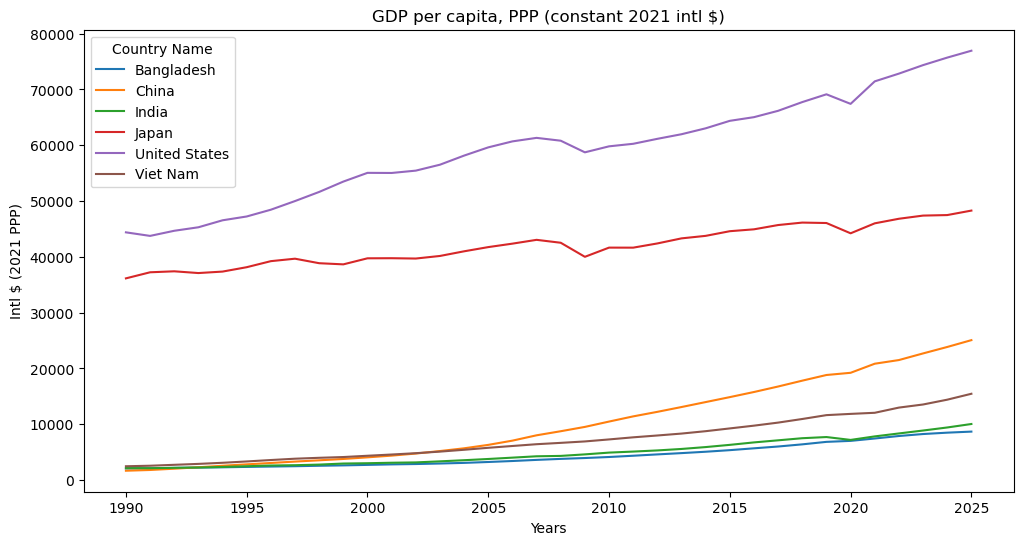

In [72]:
pivot_df.plot(figsize=(12, 6), title='GDP per capita, PPP (constant 2021 intl $)', ylabel='Intl $ (2021 PPP)')